# The Iris Classification

## Load the dataset

In [20]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
iris = datasets.load_iris()


## DataFrame Conversion

In [6]:
import matplotlib.pyplot as plt
x = iris.data
y = iris.target


In [13]:
feature_df = pd.DataFrame(
    x,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

feature_df

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [15]:
target_df = pd.DataFrame(
    y,
    columns=["target"]
)
target_df

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [19]:
final_df = pd.concat([feature_df, target_df], axis=1)
final_df

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Setosa

In [27]:
setosa_df = final_df[final_df["target"] == 0]
setosa_df[:5]

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Versicolor

In [28]:
versicolor_df = final_df[final_df["target"] == 1]
versicolor_df[:5]

,sepal_length,sepal_width,petal_length,petal_width,target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


### Virginica

In [30]:
virginica_df = final_df[final_df["target"] == 2]
virginica_df[:5]

,sepal_length,sepal_width,petal_length,petal_width,target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


# Plots

### Sepal Length vs Sepal Width

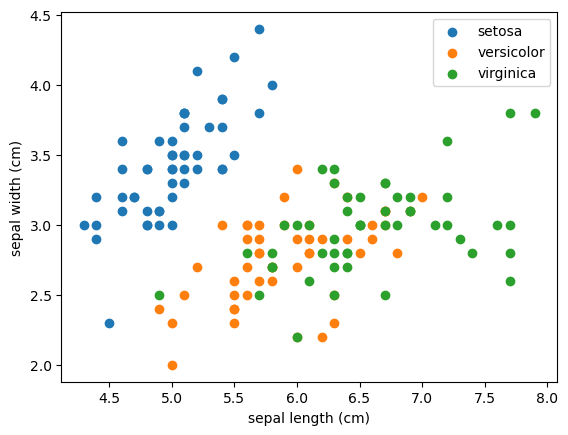

In [38]:
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.scatter(setosa_df["sepal_length"], setosa_df["sepal_width"])
plt.scatter(versicolor_df["sepal_length"], versicolor_df["sepal_width"])
plt.scatter(virginica_df["sepal_length"], virginica_df["sepal_width"])
plt.legend(
    iris.target_names
)

# KNN Classifier

## Import the Libaries

In [40]:
from sklearn.model_selection import train_test_split

## Split the Dataset

In [42]:
X = final_df.drop(['target'], axis='columns')
y = final_df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

## Build the Classifier

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
knn.score(X_test, y_test)

0.9333333333333333

## How good is our model?

In [58]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 8,  0,  0],
       [ 0, 10,  1],
       [ 0,  1, 10]])

Text(58.222222222222214, 0.5, 'Real Flower')

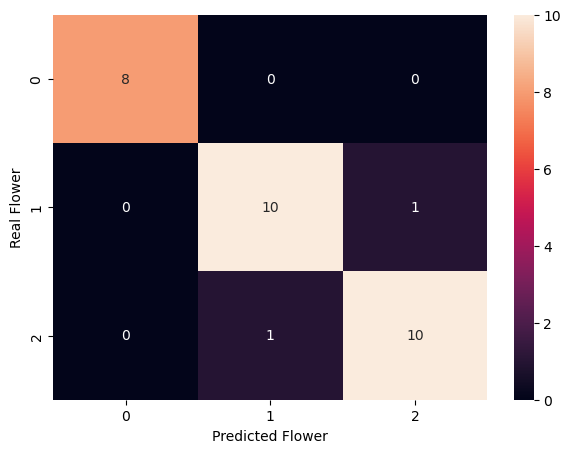

In [59]:
import seaborn as sb
plt.figure(figsize=(7,5))
sb.heatmap(cm, annot=True)
plt.xlabel("Predicted Flower")
plt.ylabel("Real Flower")